# Training DeepLabV3+ for SAR Segmentation

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Keyword 'img_size' unknown")
warnings.filterwarnings("ignore", message="Implicit dimension choice for softmax")
warnings.filterwarnings("ignore", ".*IProgress not found.*")

## Imports

In [2]:
import random
import albumentations as A
from torch.utils.data import DataLoader

import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
import ActivationExamples_SARSeg.examples_utils as utils
from ActivationExamples_SARSeg.examples_utils import *

initialized = False

## Setup

In [3]:
lmdb_path = '../data/BigEarthNet/Encoded-BigEarthNet'
parquet_path = '../data/BigEarthNet/metadata.parquet'

In [4]:
if not initialized:
    train_matches, val_matches, test_matches = match_keys(parquet_path)
    initialized = True

In [5]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
], is_check_shapes=False)

print(f"Train size: {len(train_matches)}, Val size: {len(val_matches)}, Test size: {len(test_matches)}")

train_dataset = SARSegmentationDataset120(lmdb_path, train_matches[:], transform=transform)
val_dataset = SARSegmentationDataset120(lmdb_path, val_matches[:], transform=None)
test_dataset = SARSegmentationDataset120(lmdb_path, test_matches[:], transform=None)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_train_img = len(train_dataset)
num_val_img = len(val_dataset)
num_test_img = len(test_dataset)

steps_per_epoch = num_train_img // batch_size
val_steps_per_epoch = num_val_img // batch_size
print("Steps per epoch: ", steps_per_epoch)
print("Validation steps per epoch: ", val_steps_per_epoch)

Train size: 237871, Val size: 122342, Test size: 119825
Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...
Steps per epoch:  14866
Validation steps per epoch:  7646


## Training

In [6]:
import torch.optim as optim

random.seed(42)
want_to_train = False

model = load_base_with_bigearth_pretrained_deeplabv3plus()

# Freeze encoder layers
for param in model.encoder.parameters():
    param.requires_grad = False

# RESUME SETUP (uncomment for 2nd+ run)
# checkpoint_path = "../models/deeplabv3plus120_full_checkpoint_epoch_N.pth"
# optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
# state = load_training_checkpoint(checkpoint_path, model, optimizer, scheduler)
# resume_kwargs = dict(optimizer=optimizer, scheduler=scheduler,
#                      best_val_loss=state["best_val_loss"],
#                      patience_counter=state["patience_counter"])

resume_kwargs = {}

if want_to_train:
    model, optimizer = training(
        model=model,
        epoch_start=1,
        epoch_end=20,
        train_loader=train_loader,
        val_loader=val_loader,
        num_classes=20,
        lr=1e-4,
        model_name="deeplabv3plus120_full",
        **resume_kwargs,
    )
else:
    print("Not training")

Not training


In [7]:
checkpoint_path = "../models/deeplabv3plus120_full_checkpoint_epoch_1.pth"
optimizer2 = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode="min", factor=0.5, patience=2)
state = load_training_checkpoint(checkpoint_path, model, optimizer2, scheduler2)
resume_kwargs = dict(optimizer=optimizer2, scheduler=scheduler2,
                     best_val_loss=state["best_val_loss"],
                     patience_counter=state["patience_counter"])

In [8]:
scheduler2

In [9]:
optimizer2

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)

In [10]:
resume_kwargs

{'optimizer': AdamW (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: True
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     lr: 0.0001
     maximize: False
     weight_decay: 0.0001
 ),
 'scheduler': <torch.optim.lr_scheduler.ReduceLROnPlateau at 0x20862a3dde0>,
 'best_val_loss': 3.9370326802857454,
 'patience_counter': 0}

## Evaluation

In [11]:
model_activations = load_from_checkpoint_deeplabv3plus("../models/deeplabv3plus120_full_best.pth")
model_activations.eval()

DeepLabV3Plus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequentia

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


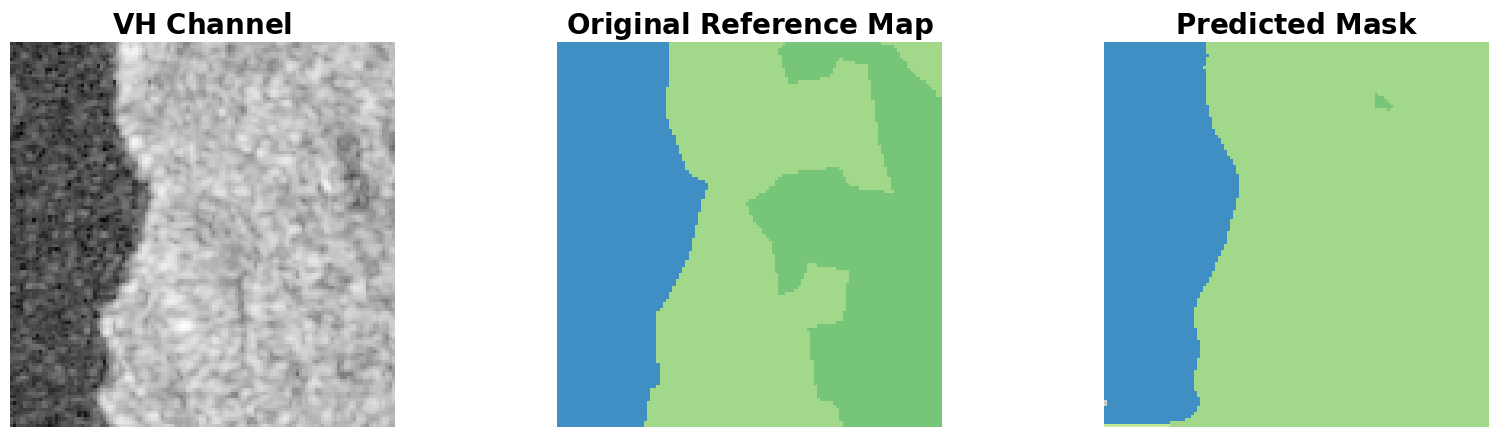

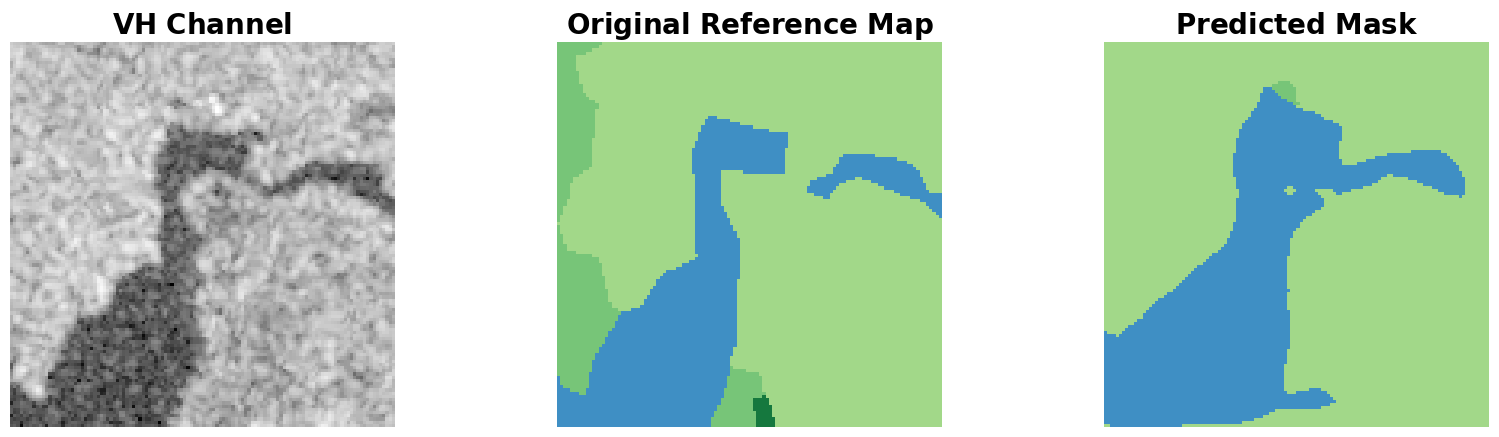

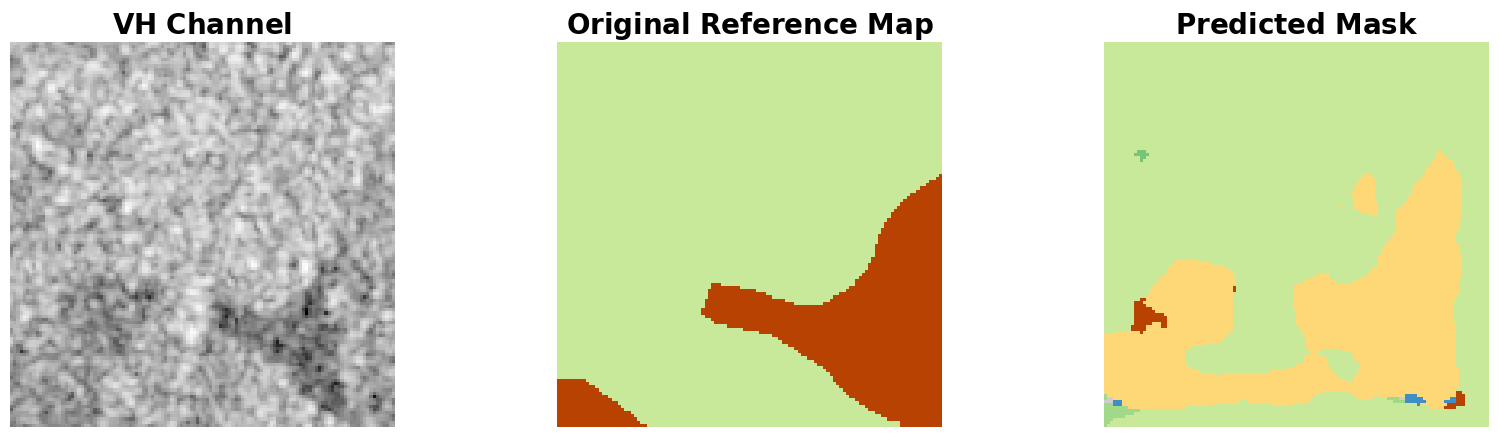

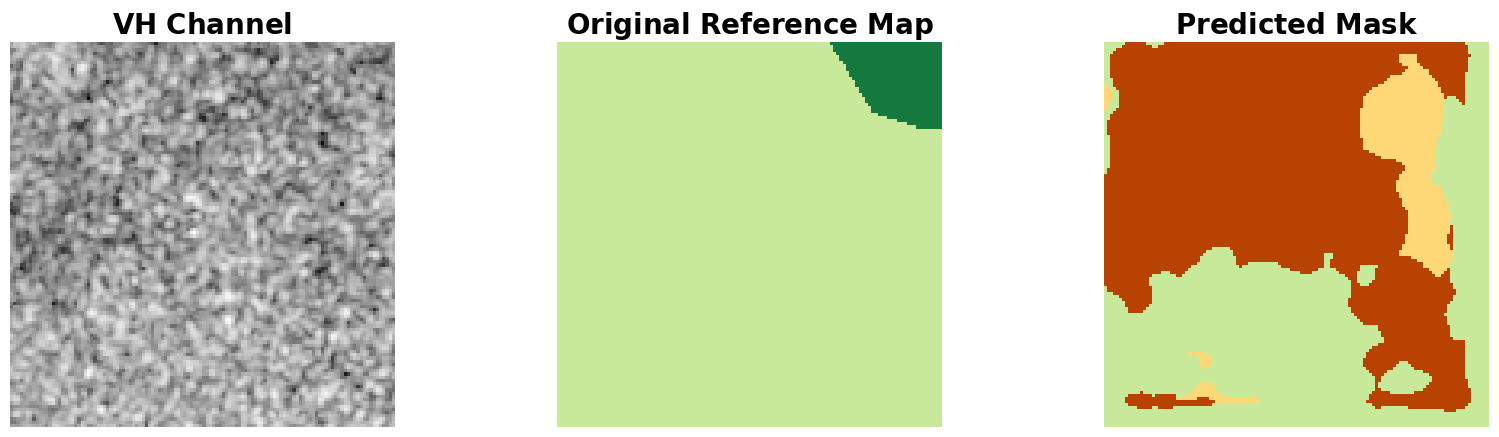

In [12]:
# Good
display_image_reference_inference(model_activations, lmdb_path, "S1B_IW_GRDH_1SDV_20180517T154802_35VNJ_55_62", "S2B_MSIL2A_20180515T094029_N9999_R036_T35VNJ_55_62_reference_map", img_size= 128)
display_image_reference_inference(model_activations, lmdb_path, "S1A_IW_GRDH_1SDV_20180526T045642_34WFU_35_21", "S2A_MSIL2A_20180526T100031_N9999_R122_T34WFU_35_21_reference_map", img_size= 128)

# Bad ? 
display_image_reference_inference(model_activations, lmdb_path, "S1B_IW_GRDH_1SDV_20180515T063421_29SNC_25_84", "S2B_MSIL2A_20180515T112109_N9999_R037_T29SNC_25_84_reference_map", img_size= 128)
display_image_reference_inference(model_activations, lmdb_path, "S1B_IW_GRDH_1SDV_20180515T063421_29SNC_44_47", "S2B_MSIL2A_20180515T112109_N9999_R037_T29SNC_44_47_reference_map", img_size= 128)

In [13]:
test_loss, test_iou, test_f1 = calculate_scores(model_activations, test_loader, device, num_classes=20)

Calculating scores: 100%|██████████| 7490/7490 [10:18<00:00, 12.10it/s]

Test Loss: 3.5879076747932483, Test IoU: 0.3963207925701556, Test F1: 0.5292994403428285
